In [31]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
import featuretools as ft

sns.set_theme(style="darkgrid", palette="deep")

plt.rcParams.update({
    "axes.grid": True,
    "axes.grid.which": "both",
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "grid.alpha": 0.7,
    "grid.linewidth": 0.6,
})

In [32]:
players = pd.read_csv("Players.csv")
player_data = pd.read_csv("player_data.csv", parse_dates=["birth_date"])
seasons_stats = pd.read_csv("Seasons_Stats.csv")

players[["born", "height", "weight"]] = players[["born", "height", "weight"]].astype("Int16")
player_data[["year_start", "year_end"]] = player_data[["year_start", "year_end"]].astype("int16")
player_data["weight"] = player_data["weight"].astype("Int16")
seasons_stats["Year"] = seasons_stats["Year"].astype("Int16")
seasons_stats["Age"] = seasons_stats["Age"].astype("Int8")
count_cols = ["G", "GS", "MP", "FG", "FGA", "3P", "3PA", "2P", "2PA", "FT", "FTA",
              "ORB", "DRB", "TRB", "AST", "STL", "BLK", "TOV", "PF", "PTS"]
seasons_stats[count_cols] = seasons_stats[count_cols].astype("Int16")

In [33]:
# Первинний аналіз даних: структура, типи колонок і пропуски
player_data.head()

,name,year_start,year_end,position,height,weight,birth_date,college
0,Alaa Abdelnaby,1991,1995,F-C,6-10,240,1968-06-24,Duke University
1,Zaid Abdul-Aziz,1969,1978,C-F,6-9,235,1946-04-07,Iowa State University
2,Kareem Abdul-Jabbar,1970,1989,C,7-2,225,1947-04-16,"University of California, Los Angeles"
3,Mahmoud Abdul-Rauf,1991,2001,G,6-1,162,1969-03-09,Louisiana State University
4,Tariq Abdul-Wahad,1998,2003,F,6-6,223,1974-11-03,San Jose State University


In [34]:
player_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4550 entries, 0 to 4549
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   name        4550 non-null   object        
 1   year_start  4550 non-null   int16         
 2   year_end    4550 non-null   int16         
 3   position    4549 non-null   object        
 4   height      4549 non-null   object        
 5   weight      4544 non-null   Int16         
 6   birth_date  4519 non-null   datetime64[ns]
 7   college     4248 non-null   object        
dtypes: Int16(1), datetime64[ns](1), int16(2), object(4)
memory usage: 209.0+ KB


In [35]:
players.head()

,Unnamed: 0,Player,height,weight,collage,born,birth_city,birth_state
0,0,Curly Armstrong,180,77,Indiana University,1918,NaN,NaN
1,1,Cliff Barker,188,83,University of Kentucky,1921,Yorktown,Indiana
2,2,Leo Barnhorst,193,86,University of Notre Dame,1924,NaN,NaN
3,3,Ed Bartels,196,88,North Carolina State University,1925,NaN,NaN
4,4,Ralph Beard,178,79,University of Kentucky,1927,Hardinsburg,Kentucky


In [36]:
players.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3922 entries, 0 to 3921
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Unnamed: 0   3922 non-null   int64 
 1   Player       3921 non-null   object
 2   height       3921 non-null   Int16 
 3   weight       3921 non-null   Int16 
 4   collage      3573 non-null   object
 5   born         3921 non-null   Int16 
 6   birth_city   3452 non-null   object
 7   birth_state  3439 non-null   object
dtypes: Int16(3), int64(1), object(4)
memory usage: 187.8+ KB


In [37]:
seasons_stats.head()

,Unnamed: 0,Year,Player,Pos,Age,Tm,G,GS,MP,PER,...,FT%,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS
0,0,1950,Curly Armstrong,G-F,31,FTW,63,<NA>,<NA>,NaN,...,0.705,<NA>,<NA>,<NA>,176,<NA>,<NA>,<NA>,217,458
1,1,1950,Cliff Barker,SG,29,INO,49,<NA>,<NA>,NaN,...,0.708,<NA>,<NA>,<NA>,109,<NA>,<NA>,<NA>,99,279
2,2,1950,Leo Barnhorst,SF,25,CHS,67,<NA>,<NA>,NaN,...,0.698,<NA>,<NA>,<NA>,140,<NA>,<NA>,<NA>,192,438
3,3,1950,Ed Bartels,F,24,TOT,15,<NA>,<NA>,NaN,...,0.559,<NA>,<NA>,<NA>,20,<NA>,<NA>,<NA>,29,63
4,4,1950,Ed Bartels,F,24,DNN,13,<NA>,<NA>,NaN,...,0.548,<NA>,<NA>,<NA>,20,<NA>,<NA>,<NA>,27,59


In [38]:
seasons_stats.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24691 entries, 0 to 24690
Data columns (total 53 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  24691 non-null  int64  
 1   Year        24624 non-null  Int16  
 2   Player      24624 non-null  object 
 3   Pos         24624 non-null  object 
 4   Age         24616 non-null  Int8   
 5   Tm          24624 non-null  object 
 6   G           24624 non-null  Int16  
 7   GS          18233 non-null  Int16  
 8   MP          24138 non-null  Int16  
 9   PER         24101 non-null  float64
 10  TS%         24538 non-null  float64
 11  3PAr        18839 non-null  float64
 12  FTr         24525 non-null  float64
 13  ORB%        20792 non-null  float64
 14  DRB%        20792 non-null  float64
 15  TRB%        21571 non-null  float64
 16  AST%        22555 non-null  float64
 17  STL%        20792 non-null  float64
 18  BLK%        20792 non-null  float64
 19  TOV%        19582 non-nul

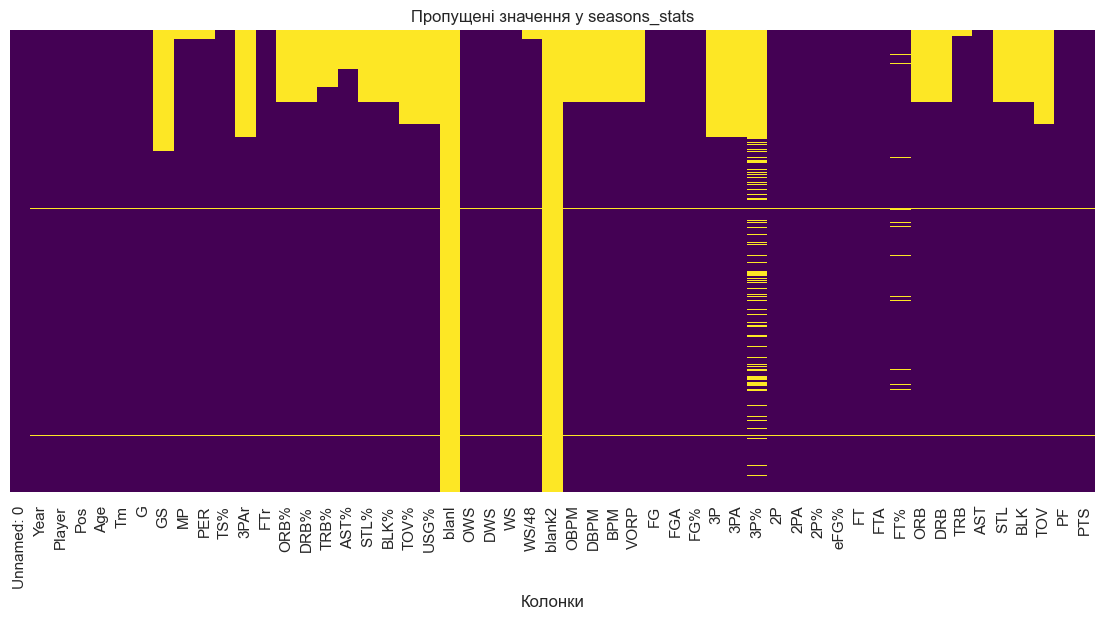

In [39]:
# Графік 1. Карта пропущених значень у seasons_stats
plt.figure(figsize=(14, 6))
sns.heatmap(seasons_stats.isna(), cbar=False, cmap="viridis", yticklabels=False)
plt.title("Пропущені значення у seasons_stats")
plt.xlabel("Колонки")
plt.show()

In [40]:
# Дві колонки (blanl, blank2) повністю порожні - їх видаляємо. Жовті смуги вгорі - найстаріші сезони, де частину показників не рахували.

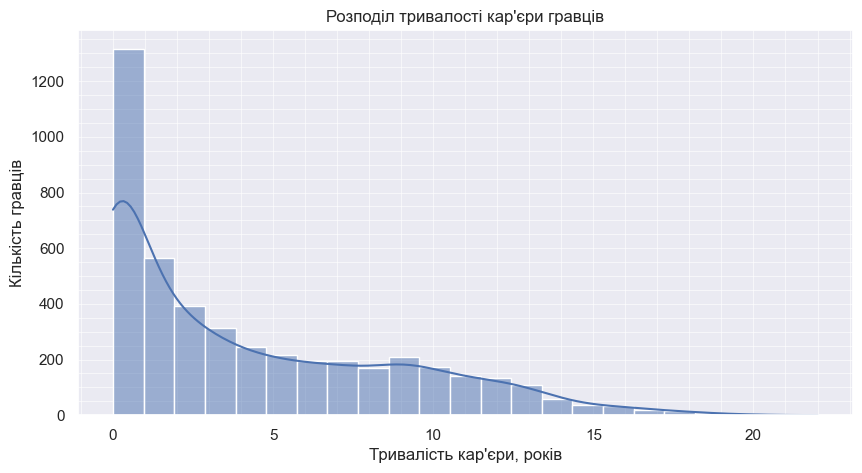

In [41]:
# Графік 2. Тривалість кар'єри (роки в лізі)
player_data["career"] = player_data["year_end"] - player_data["year_start"]

plt.figure(figsize=(10, 5))
sns.histplot(data=player_data, x="career", kde=True, bins=23)
plt.title("Розподіл тривалості кар'єри гравців")
plt.xlabel("Тривалість кар'єри, років")
plt.ylabel("Кількість гравців")
plt.show()

In [42]:
# Розподіл сильно перекошений: коротких кар'єр дуже багато, довгих мало.

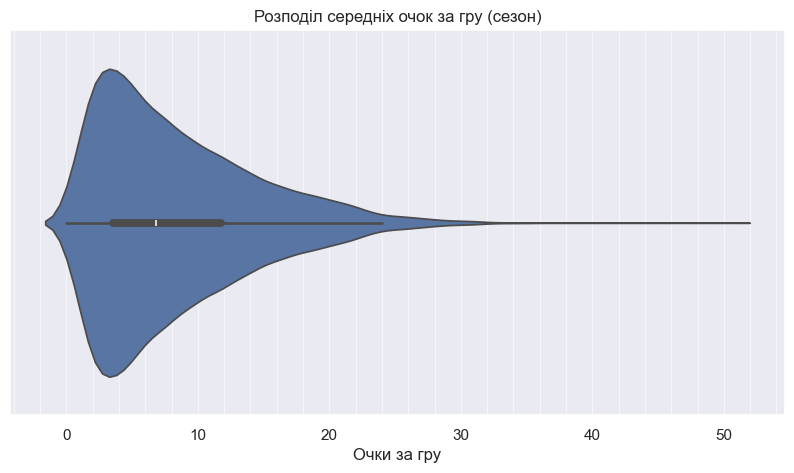

In [43]:
# Графік 3. Розподіл очок за гру
seasons_stats["PTS_per_G"] = seasons_stats["PTS"] / seasons_stats["G"]

plt.figure(figsize=(10, 5))
sns.violinplot(data=seasons_stats, x="PTS_per_G")
plt.title("Розподіл середніх очок за гру (сезон)")
plt.xlabel("Очки за гру")
plt.show()

In [44]:
# Очки за гру теж перекошені вправо: більшість набирає небагато, але є рідкісні дуже високі значення (точка після 30).

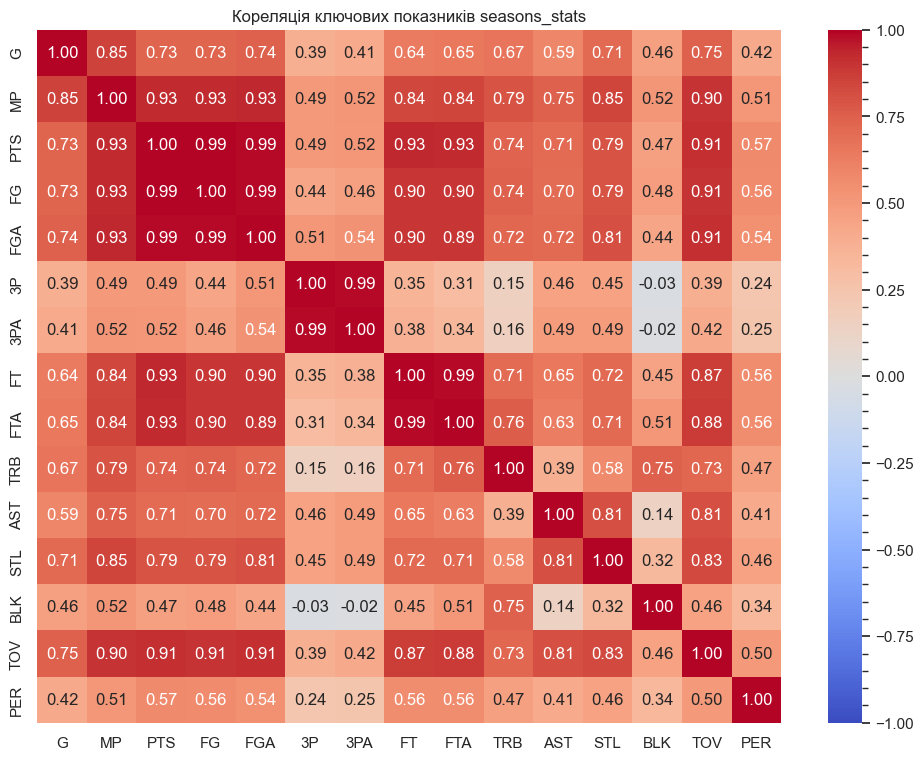

In [45]:
# Графік 4. Кореляційна матриця ключових показників
cols = ["G", "MP", "PTS", "FG", "FGA", "3P", "3PA", "FT", "FTA",
        "TRB", "AST", "STL", "BLK", "TOV", "PER"]
corr = seasons_stats[cols].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Кореляція ключових показників seasons_stats")
plt.show()

In [46]:
# Багато показників майже повторюють одне одного (наприклад очки й кидки) - бо ростуть разом зі зіграним часом. Якщо дві колонки настільки схожі, для моделі досить однієї, другу можна прибрати. А PER стоїть окремо - він майже не залежить від обсягів і дає нову інформацію.

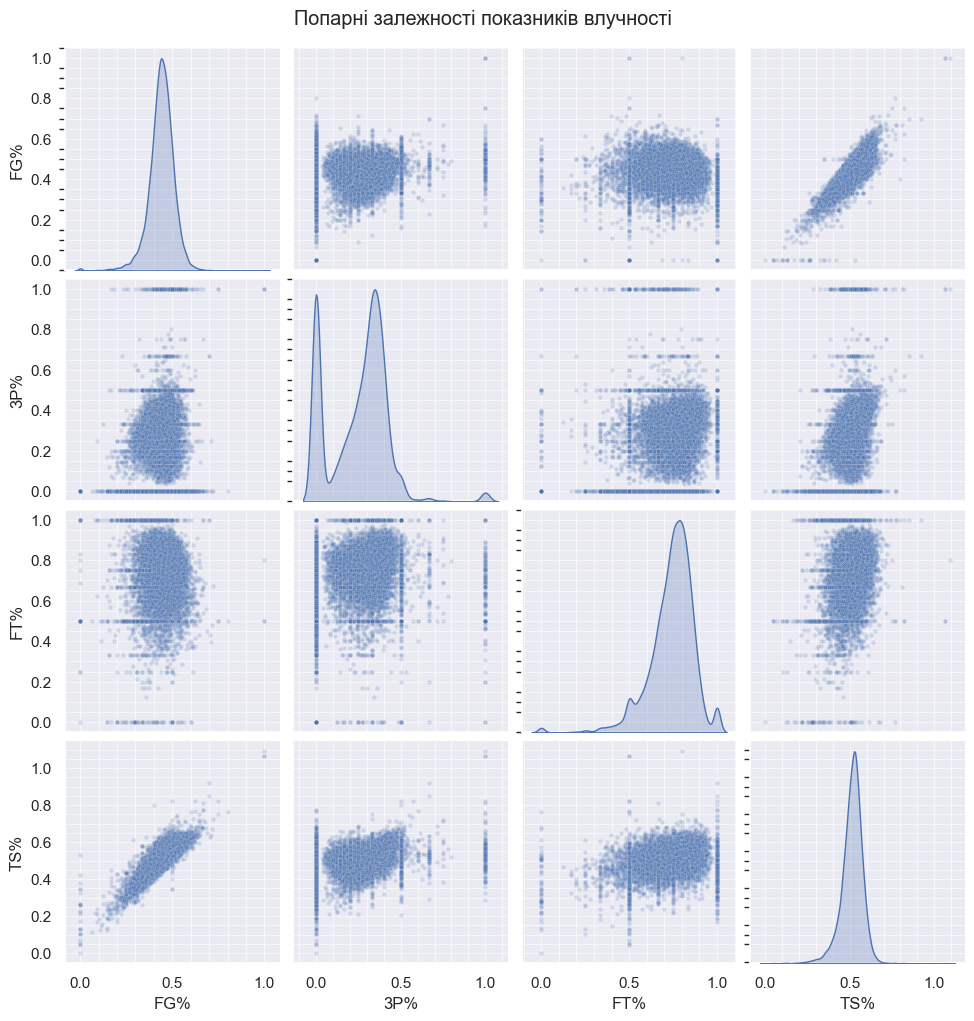

In [47]:
# Графік 5. pairplot показників влучності
cols = ["FG%", "3P%", "FT%", "TS%"]
subset = seasons_stats[cols].dropna()

sns.pairplot(subset, diag_kind="kde", plot_kws={"alpha": 0.2, "s": 10})
plt.suptitle("Попарні залежності показників влучності", y=1.02)
plt.show()

In [48]:
# FG% і TS% майже однакові (точки лягають в одну лінію) - для моделі досить однієї з них. А FG% і 3P% незалежні: кидати зблизька й здалеку - різні вміння, тож обидві ознаки корисні. У 3P% багато нулів - це можна окремо позначити ознакою «чи кидає трійки».

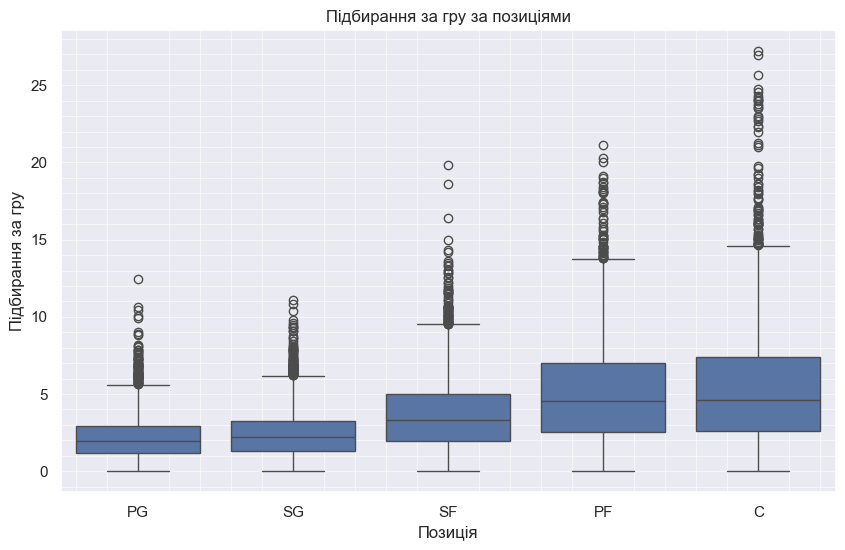

In [49]:
# Графік 6. Підбирання за гру по позиціях
seasons_stats["TRB_per_G"] = seasons_stats["TRB"] / seasons_stats["G"]

main_pos = ["PG", "SG", "SF", "PF", "C"]
df_pos = seasons_stats[seasons_stats["Pos"].isin(main_pos)]

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_pos, x="Pos", y="TRB_per_G", order=main_pos)
plt.title("Підбирання за гру за позиціями")
plt.xlabel("Позиція")
plt.ylabel("Підбирання за гру")
plt.show()

In [50]:
# Позиція явно впливає на підбирання (великі беруть більше). Отже Pos - корисна ознака, але її треба перетворити на числа. Окремі точки зверху - викиди, про які варто пам'ятати.

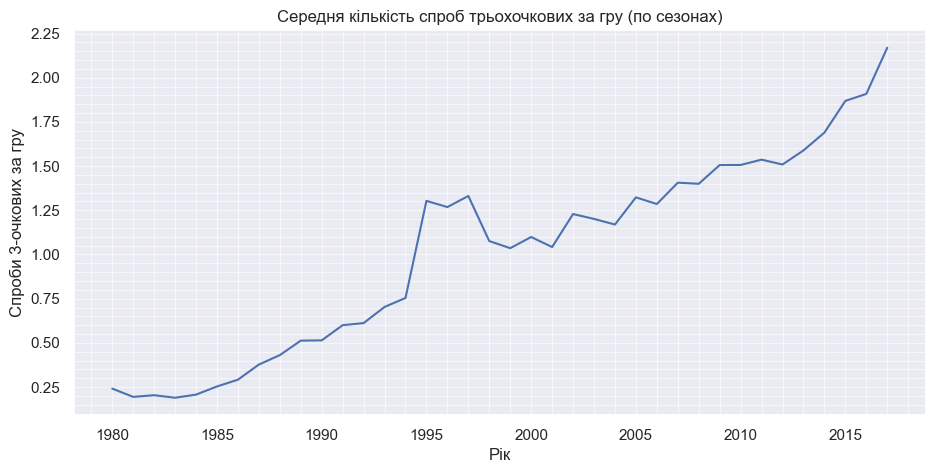

In [51]:
# Графік 7. Середні спроби трьохочкових за гру по сезонах
seasons_stats["3PA_per_G"] = seasons_stats["3PA"] / seasons_stats["G"]
trend = seasons_stats.groupby("Year")["3PA_per_G"].mean()

plt.figure(figsize=(11, 5))
sns.lineplot(x=trend.index, y=trend.values)
plt.title("Середня кількість спроб трьохочкових за гру (по сезонах)")
plt.xlabel("Рік")
plt.ylabel("Спроби 3-очкових за гру")
plt.show()

In [52]:
# Кількість трійок сильно змінюється з роками - тобто гра з часом стає іншою, і рік корисно додати як ознаку. Головне: до 1980 трійок не існувало, тому там пропуски означають нуль - саме нулем їх і правильно заповнювати, а не середнім.

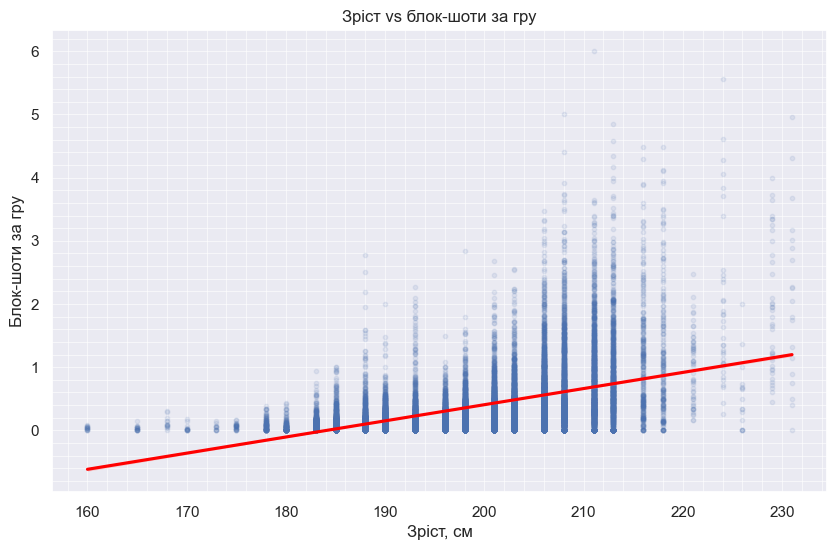

In [53]:
# Графік 8. Зріст vs блок-шоти за гру (після merge з players)
merged = seasons_stats.merge(players[["Player", "height"]], on="Player", how="left")
merged["BLK_per_G"] = merged["BLK"] / merged["G"]

plt.figure(figsize=(10, 6))
sns.regplot(data=merged, x="height", y="BLK_per_G",
            scatter_kws={"alpha": 0.1, "s": 10}, line_kws={"color": "red"})
plt.title("Зріст vs блок-шоти за гру")
plt.xlabel("Зріст, см")
plt.ylabel("Блок-шоти за гру")
plt.show()

In [54]:
# Зріст трохи допомагає передбачити блок-шоти (лінія йде вгору), але слабко - точки розкидані широко. Сам по собі він мало що дає, корисний хіба в парі з іншими ознаками.

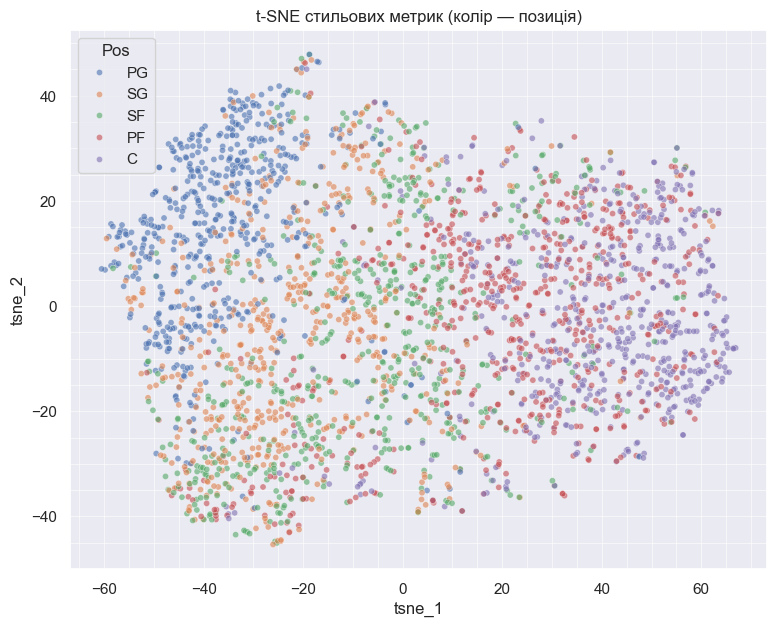

In [55]:
# Графік 9. t-SNE стильових метрик, колір за позицією
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

feats = ["TS%", "3PAr", "FTr", "TRB%", "AST%", "STL%", "BLK%", "TOV%", "USG%"]
data = seasons_stats[seasons_stats["Pos"].isin(main_pos)].dropna(subset=feats)
data = data.sample(3000, random_state=42).copy()

X = StandardScaler().fit_transform(data[feats])
emb = TSNE(n_components=2, random_state=42, init="pca", perplexity=30).fit_transform(X)
data["tsne_1"], data["tsne_2"] = emb[:, 0], emb[:, 1]

plt.figure(figsize=(9, 7))
sns.scatterplot(data=data, x="tsne_1", y="tsne_2", hue="Pos",
                hue_order=main_pos, alpha=0.6, s=20)
plt.title("t-SNE стильових метрик (колір — позиція)")
plt.show()

In [56]:
# За цими метриками позиції справді відрізняються - тобто вони добре описують стиль гравця і годяться як ознаки. Але групи плавно переходять одна в одну без чіткої межі.

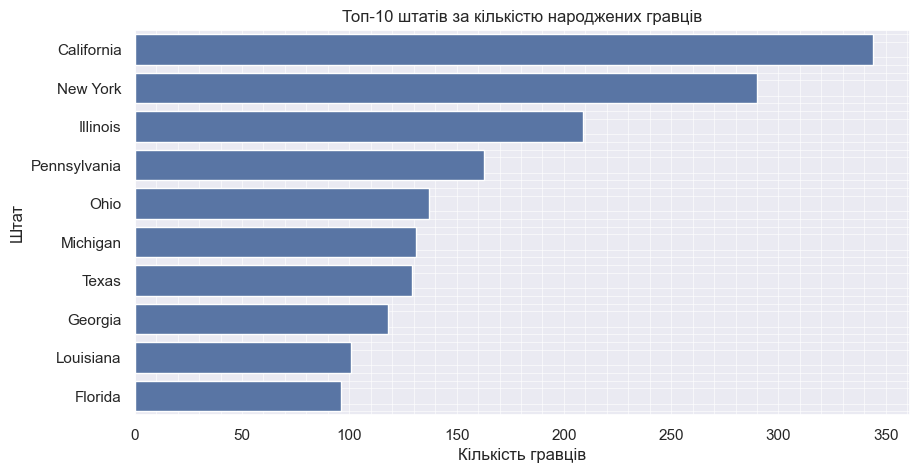

In [57]:
# Графік 10. Топ-10 штатів народження
top_states = players["birth_state"].value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_states.values, y=top_states.index)
plt.title("Топ-10 штатів за кількістю народжених гравців")
plt.xlabel("Кількість гравців")
plt.ylabel("Штат")
plt.show()

In [58]:
# birth_state по суті повторює населення штату, тож користі для прогнозу від нього мало. До того ж різних штатів багато: якщо кодувати кожен окремою колонкою, таблиця сильно роздується - краще їх згрупувати.

In [59]:
# Автоматична генерація фіч (FeatureTools)
# Дані як дві пов'язані таблиці (гравці -> сезони), агрегуємо статистику сезонів
# Батьки: унікальні гравці (1 рядок на гравця)
parent = (player_data.drop_duplicates("name")
          .rename(columns={"name": "Player"})[["Player", "weight", "career"]]
          .reset_index(drop=True))

# Діти: сезони; прибираємо '*' у зіркових гравців і рядки без імені.
# Додаємо категоріальні колонки Pos (позиція) і Tm (команда)
child = seasons_stats.dropna(subset=["Player"]).copy()
child["Player"] = child["Player"].str.rstrip("*")
child = child[["Player", "G", "MP", "PTS", "TRB", "AST", "PER", "Pos", "Tm"]].reset_index(drop=True)

# EntitySet + зв'язок 'один гравець -> багато сезонів'.
# Pos і Tm явно позначаємо як категоріальні, щоб працювали mode / num_unique
es = ft.EntitySet(id="nba")
es = es.add_dataframe(dataframe_name="players", dataframe=parent, index="Player")
es = es.add_dataframe(dataframe_name="seasons", dataframe=child,
                      index="season_id", make_index=True,
                      logical_types={"Pos": "Categorical", "Tm": "Categorical"})
es = es.add_relationship("players", "Player", "seasons", "Player")

# Числові (mean/max/sum) + категоріальні (mode/num_unique) агрегати
feature_matrix, feature_defs = ft.dfs(
    entityset=es, target_dataframe_name="players",
    agg_primitives=["mean", "max", "sum", "count", "mode", "num_unique"],
    trans_primitives=[], max_depth=1)

print("Автоматично згенеровано фіч:", feature_matrix.shape[1])
feature_matrix.head()

Автоматично згенеровано фіч: 25


,weight,career,COUNT(seasons),MAX(seasons.AST),MAX(seasons.G),MAX(seasons.MP),MAX(seasons.PER),MAX(seasons.PTS),MAX(seasons.TRB),MEAN(seasons.AST),...,MODE(seasons.Pos),MODE(seasons.Tm),NUM_UNIQUE(seasons.Pos),NUM_UNIQUE(seasons.Tm),SUM(seasons.AST),SUM(seasons.G),SUM(seasons.MP),SUM(seasons.PER),SUM(seasons.PTS),SUM(seasons.TRB)
Player,,,,,,,,,,,,,,,,,,,,,
Alaa Abdelnaby,240,4,9,30.0,75.0,1311.0,14.1,578.0,337.0,13.888889,...,PF,BOS,1,6,125.0,385.0,5017.0,88.5,2299.0,1297.0
Zaid Abdul-Aziz,235,9,14,166.0,80.0,2459.0,17.1,865.0,923.0,46.285714,...,C,HOU,4,7,648.0,570.0,12126.0,192.5,4978.0,4524.0
Kareem Abdul-Jabbar,225,19,20,431.0,82.0,3583.0,29.9,2822.0,1383.0,283.000000,...,C,LAL,1,2,5660.0,1560.0,57446.0,481.7,38387.0,17440.0
Mahmoud Abdul-Rauf,162,10,9,389.0,81.0,2710.0,18.6,1553.0,225.0,231.000000,...,PG,DEN,1,3,2079.0,586.0,15628.0,133.9,8553.0,1087.0
Tariq Abdul-Wahad,223,5,10,98.0,61.0,1578.0,14.4,697.0,291.0,38.800000,...,SG,DEN,1,5,388.0,321.0,6826.0,99.3,2662.0,1151.0


In [60]:
# Бібліотека сама зробила 25 готових ознак про кожного гравця - середні/макс/сума за кар'єру плюс категоріальні (основна позиція, головна команда, скільки команд і позицій). Їх можна одразу використати в моделі, не рахуючи вручну.